# Projet ML — German Credit Risk
**Objectif :** Prédire si un client est un *bon* (1) ou *mauvais* (2) payeur.
**Dataset :** Statlog German Credit Data (UCI) — 1 000 instances, 20 attributs.

---

Imports et Configuration du projet et dependances.

In [1]:
from importlib.metadata import Distribution

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#IMPORTS
from sklearn.model_selection import train_test_split,validation_curve,GridSearchCV,learning_curve,cross_val_score,StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, Normalizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,roc_auc_score, auc, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline



# 1. Exploration des Donnnees (EDA)

Chargement du Dataset


Statistique Descriptive 

       checking_status     duration credit_history purpose  credit_amount  \
count             1000  1000.000000           1000    1000    1000.000000   
unique               4          NaN              5      10            NaN   
top                A14          NaN            A32     A43            NaN   
freq               394          NaN            530     280            NaN   
mean               NaN    20.903000            NaN     NaN    3271.258000   
std                NaN    12.058814            NaN     NaN    2822.736876   
min                NaN     4.000000            NaN     NaN     250.000000   
25%                NaN    12.000000            NaN     NaN    1365.500000   
50%                NaN    18.000000            NaN     NaN    2319.500000   
75%                NaN    24.000000            NaN     NaN    3972.250000   
max                NaN    72.000000            NaN     NaN   18424.000000   

       savings_status employment  installment_rat

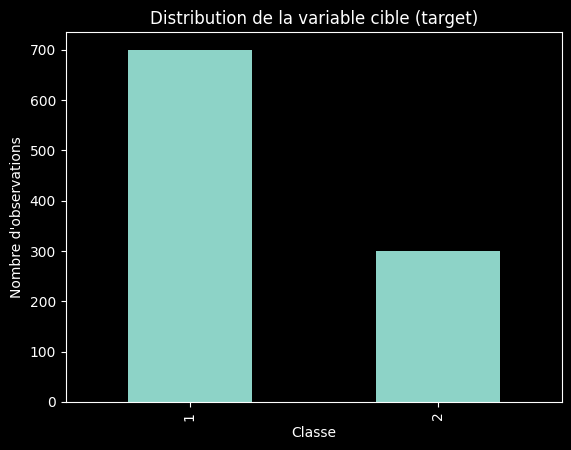

In [2]:
# Noms des colonnes selon german.doc
col_names = [
    'checking_status',   # A1  - qualitatif
    'duration',          # A2  - numérique  (mois)
    'credit_history',    # A3  - qualitatif
    'purpose',           # A4  - qualitatif
    'credit_amount',     # A5  - numérique  (DM)
    'savings_status',    # A6  - qualitatif
    'employment',        # A7  - qualitatif
    'installment_rate',  # A8  - numérique  (%)
    'personal_status',   # A9  - qualitatif
    'other_debtors',     # A10 - qualitatif
    'residence_since',   # A11 - numérique
    'property',          # A12 - qualitatif
    'age',               # A13 - numérique
    'other_plans',       # A14 - qualitatif
    'housing',           # A15 - qualitatif
    'existing_credits',  # A16 - numérique
    'job',               # A17 - qualitatif
    'liable_people',     # A18 - numérique
    'telephone',         # A19 - qualitatif
    'foreign_worker',    # A20 - qualitatif
    'target'             # A21 - cible (1=bon, 2=mauvais)
]


df = pd.read_csv('data/german.data', sep=' ', header=None, names=col_names)

#Statistique Descriptive
print("Statistique Descriptive \n")
Stats = df.describe(include="all")
print(Stats)

#Afficher les premiere ligne du Dataset
print("Affichage des 5 premiere lignes :")
print(df.head())


#Type de variables
DataType = df.dtypes
print( f'Type des data : {DataType}' )

#Afficher variables Cibles
class_counts = df['target'].value_counts()
print(f' Balance des calsses : {class_counts}')

# graphique
df["target"].value_counts().plot(kind="bar")
plt.title("Distribution de la variable cible (target)")
plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")
plt.show()



## 700 Bon payeur et 300 Mauvais payeur

## 2. Préparation des Données (Data Engineering)
Nettoyage : Détection et nettoyage des valeurs manquantes.

Encodage : Conversion des variables catégorielles en données numériques. (si nécéssaire)

Feature Scaling : Mise à l'échelle des données (Standardisation ou Normalisation avec justification),

In [3]:
#Nettoyage : 'target'

Null = df.isnull().sum()
print(f' Nombres de variables NUll : {Null}')
# 0 Valeurs Manquante

#Encodage : categoriel a numerique
Le = LabelEncoder()
X = df.drop("target", axis=1)
y = df["target"]

for col in X.columns:
    if X[col].dtype == "str":
        print("Encodage de la colonne :", col)
        X[col] = Le.fit_transform(X[col])

#Appercus des colonne encoder
print(f" Variable Encoder : {X} ")


 Nombres de variables NUll : checking_status     0
duration            0
credit_history      0
purpose             0
credit_amount       0
savings_status      0
employment          0
installment_rate    0
personal_status     0
other_debtors       0
residence_since     0
property            0
age                 0
other_plans         0
housing             0
existing_credits    0
job                 0
liable_people       0
telephone           0
foreign_worker      0
target              0
dtype: int64
Encodage de la colonne : checking_status
Encodage de la colonne : credit_history
Encodage de la colonne : purpose
Encodage de la colonne : savings_status
Encodage de la colonne : employment
Encodage de la colonne : personal_status
Encodage de la colonne : other_debtors
Encodage de la colonne : property
Encodage de la colonne : other_plans
Encodage de la colonne : housing
Encodage de la colonne : job
Encodage de la colonne : telephone
Encodage de la colonne : foreign_worker
 Variable Encoder 

## Normalisation

In [4]:
#Features Scaling : 'target' Avec NORMALISATION

#Separer les Data test et train
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2,random_state=42)

normScaler = StandardScaler()
normScaler.fit_transform(X_train)


X_train_scaled = normScaler.transform(X_train)
X_test_scaled = normScaler.transform(X_test)


# 4. Vérifier le résultat
print(f" Variable Encoder : {X_train_scaled} ")


 Variable Encoder : [[-1.27298066  3.29708155  0.42039443 ... -0.40973554  1.1751393
  -0.19044535]
 [ 0.31700299 -0.00805096  1.33678555 ... -0.40973554 -0.85096294
  -0.19044535]
 [ 1.11199481 -1.27925578 -0.49599669 ... -0.40973554 -0.85096294
  -0.19044535]
 ...
 [ 1.11199481  0.24619     1.33678555 ... -0.40973554 -0.85096294
  -0.19044535]
 [-0.47798883 -0.77077385 -0.49599669 ... -0.40973554  1.1751393
  -0.19044535]
 [ 1.11199481 -1.27925578  0.42039443 ... -0.40973554 -0.85096294
  -0.19044535]] 


## Justification :

La mise à l’échelle des données a été réalisée à l’aide de la méthode StandardScaler. Cette technique permet de standardiser les variables en centrant les données autour de zéro et en réduisant l’influence des variables ayant des valeurs élevées. Cette étape est particulièrement importante pour les modèles basés sur la distance comme k-NN , Decison tree ou Naive Bayes.



## Modelisation

K-NN -
Decison tree -
Naive Bayes

In [5]:
knn = KNeighborsClassifier(n_neighbors=9 , metric='euclidean')

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)


accuracy_knn = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy_knn)
#0.785 = 78%



Accuracy : 0.78


## La precison est de 77% avec la methode K-NN en Utilisant 80% des donnees et 20% pour les tests

Utiliser de StandardScaler pour normaliser les donnes et on a evaluer a l'aide de accuracy_score pour teester sa precision


## Arbre de decision

In [6]:
#Decision Tree
Arbre = DecisionTreeClassifier(random_state= 42, max_depth=3 )

Arbre.fit(X_train_scaled, y_train)

y_pred = Arbre.predict(X_test_scaled)

#Accuracy

accuracy_tree = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy_tree)

# 73%

Accuracy : 0.755


## Naive Bayes

In [7]:
NB = GaussianNB(var_smoothing= 1e-08)
NB.fit(X_train_scaled, y_train)

#Prediction
y_pred = NB.predict(X_test_scaled)

accuracy_nb = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy_nb)
# 70%

Accuracy : 0.7


## Comparaison des modèles
Après l’entraînement des différents modèles, nous obtenons les résultats suivants :
- Le modèle k-NN obtient une accuracy d’environ 78%.
- Le modèle Decision Tree atteint une accuracy d’environ 73%.
- Le modèle Naive Bayes obtient une accuracy d’environ 70%.
On observe que le modèle k-NN est le plus performant parmi les trois modèles testés. Cela peut s’expliquer par le fait que k-NN exploite efficacement la similarité entre les observations.
Le modèle Decision Tree offre des résultats corrects, mais reste légèrement moins performant que k-NN. Quant au modèle Naive Bayes, il présente les performances les plus faibles, probablement en raison de ses hypothèses simplificatrices.
En conclusion, le modèle k-NN semble être le plus adapté pour ce problème. Toutefois, une optimisation des paramètres (par exemple avec GridSearch) pourrait améliorer davantage les performances des modèles.

In [8]:
results = pd.DataFrame({
    "Modèle": ["k-NN", "Decision Tree", "Naive Bayes"],
    "Accuracy": [accuracy_knn, accuracy_tree, accuracy_nb]
})

print(results)

          Modèle  Accuracy
0           k-NN     0.780
1  Decision Tree     0.755
2    Naive Bayes     0.700


## 4. Optimisation et Diagnostic
Validation : Utilisation de Grid Search et Cross-Validation pour trouver les meilleurs paramètres.

Graphiques : Tracer la Validation Curve (pour un paramètre précis) et la Learning Curve (pour analyser le comportement du modèle face au volume de données)

In [9]:
## Grid Search

param_grid_knn = {

    'n_neighbors': [3, 5, 7, 9, 11, 13, 15]

}
#KNN
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=10,
    scoring='accuracy'
)

# Résultat
grid_knn.fit(X_train_scaled, y_train)
print(f'Meilleur parametre (knn):  {grid_knn.best_params_}')
print(f'Meilleur parametre (knn): {grid_knn.best_score_} \n')
#Arbre de decision
param_grid_tree = {
    'max_depth': [3, 5, 7, 9, 13]
}

# Grid Search
grid_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state= 42 ),
    param_grid=param_grid_tree,
    cv=10,
    scoring='accuracy'
)

grid_tree.fit(X_train, y_train)

# Résultat
print("Meilleur max_depth (tree) :", grid_tree.best_params_)
print("Meilleur score CV (tree) : " , grid_tree.best_score_)
print("\n")
#Naive Bayes
param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

# Grid Search
grid_nb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid_nb,
    cv=5,
    scoring='accuracy'
)

# Entraîner
grid_nb.fit(X_train, y_train)

# Résultat
print("Meilleur var_smoothing :", grid_nb.best_params_)
print("Meilleur score CV :", grid_nb.best_score_)




Meilleur parametre (knn):  {'n_neighbors': 9}
Meilleur parametre (knn): 0.7575000000000001 

Meilleur max_depth (tree) : {'max_depth': 3}
Meilleur score CV (tree) :  0.7525000000000001


Meilleur var_smoothing : {'var_smoothing': 1e-08}
Meilleur score CV : 0.74


## Graphique K-NN


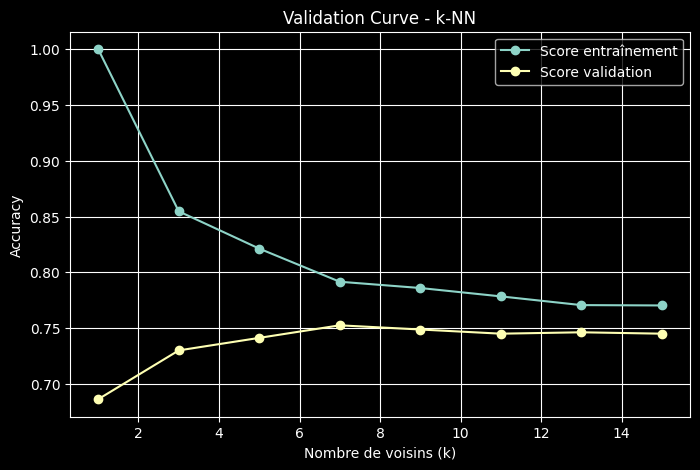

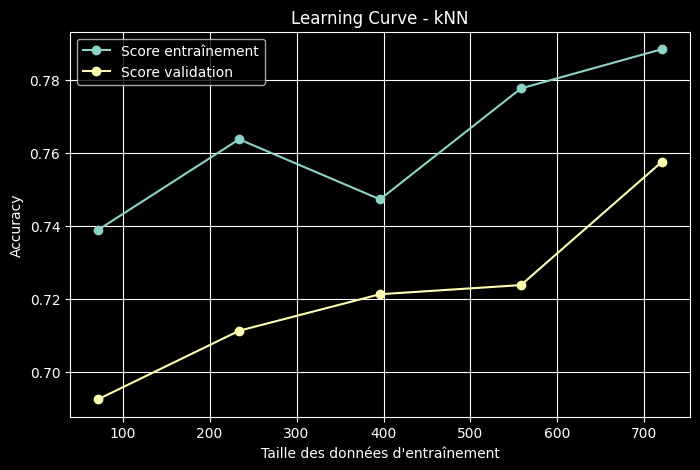

In [10]:
param_range = [1, 3, 5, 7, 9, 11, 13, 15]

train_scores, test_scores = validation_curve(
    KNeighborsClassifier(metric='euclidean'),
    X_train_scaled,
    y_train,
    param_name="n_neighbors",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, marker='o', label="Score entraînement")
plt.plot(param_range, test_mean, marker='o', label="Score validation")

plt.title("Validation Curve - k-NN")
plt.xlabel("Nombre de voisins (k)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

#================================================================
# learnign curve
#================================================================

best_knn = grid_knn.best_estimator_

train_sizes, train_scores, test_scores = learning_curve(
   best_knn,
   X_train_scaled,
   y_train,
   cv=10,
   scoring='accuracy',
   train_sizes=np.linspace(0.1, 1.0, 5)
)
# moyenne des scores
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
# graphique
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label="Score entraînement")
plt.plot(train_sizes, test_mean, marker='o', label="Score validation")
plt.title("Learning Curve - kNN")
plt.xlabel("Taille des données d'entraînement")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Graphique Arbre de Decison

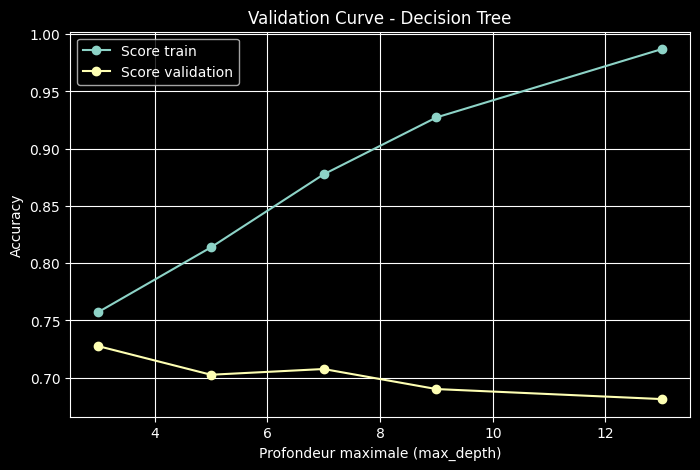

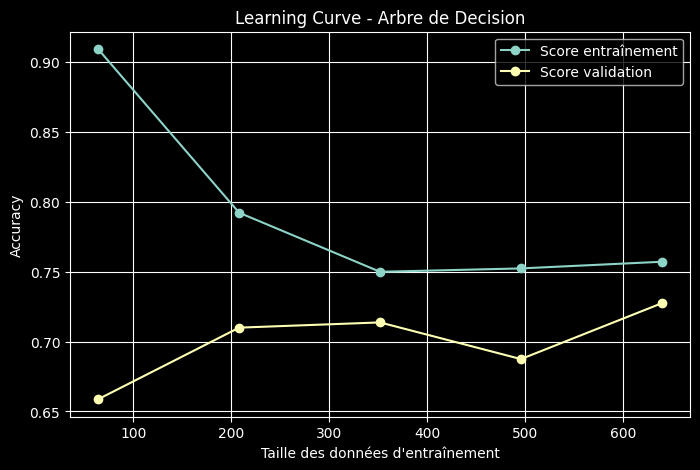

In [11]:
# Arbre de décision — Validation Curve
param_grid_tree = {
    'max_depth': [3, 5, 7, 9, 13]
}

train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train,
    y_train,
    param_name="max_depth",
    param_range=param_grid_tree['max_depth'],
    cv=5,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean  = np.mean(test_scores,  axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_grid_tree['max_depth'], train_mean, marker='o', label="Score train")
plt.plot(param_grid_tree['max_depth'], test_mean,  marker='o', label="Score validation")

plt.title("Validation Curve - Decision Tree")
plt.xlabel("Profondeur maximale (max_depth)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



#=============================================
#Learning Curve
#============================================
best_tree = grid_tree.best_estimator_

train_sizes, train_scores, test_scores = learning_curve(
   best_tree,
   X_train_scaled,
   y_train,
   cv=5,
   scoring='accuracy',
   train_sizes=np.linspace(0.1, 1.0, 5)
)
# moyenne des scores
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
# graphique
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label="Score entraînement")
plt.plot(train_sizes, test_mean, marker='o', label="Score validation")
plt.title("Learning Curve - Arbre de Decision")
plt.xlabel("Taille des données d'entraînement")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()





## Naive Bayes


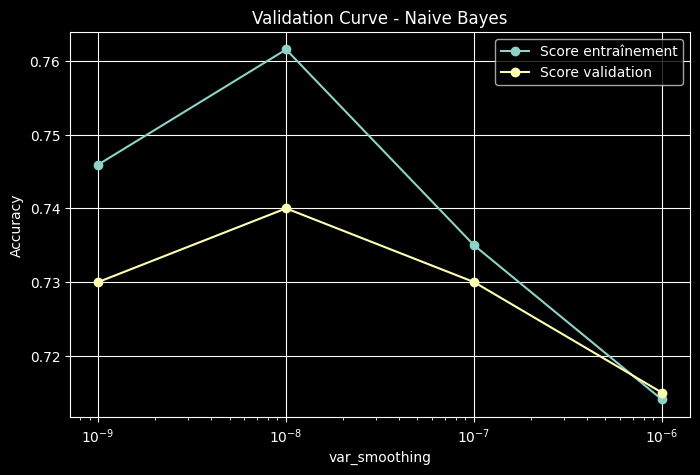

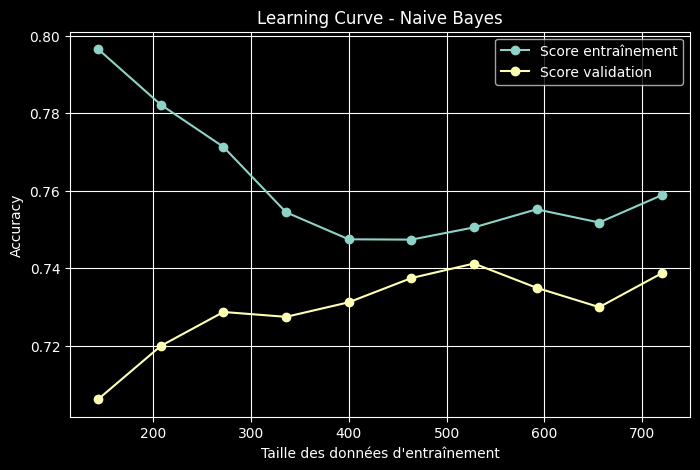

In [12]:
# ================================================================
# Validation Curve — Naive Bayes
# ================================================================
param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

train_scores, test_scores = validation_curve(
    GaussianNB(),
    X_train,
    y_train,
    param_name="var_smoothing",
    param_range=param_grid_nb['var_smoothing'],
    cv=5,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean  = np.mean(test_scores,  axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_grid_nb['var_smoothing'], train_mean, marker='o', label="Score entraînement")
plt.plot(param_grid_nb['var_smoothing'], test_mean,  marker='o', label="Score validation")

plt.title("Validation Curve - Naive Bayes")
plt.xlabel("var_smoothing")
plt.ylabel("Accuracy")
plt.xscale('log')
plt.legend()
plt.grid()
plt.show()

# ================================================================
# Learning Curve — Naive Bayes
# ================================================================
best_nb = grid_nb.best_estimator_

N, train_scores, val_scores = learning_curve(
    best_nb,
    X_train,
    y_train,
    train_sizes=np.linspace(0.2, 1.0, 10),
    cv=10,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores,   axis=1)

plt.figure(figsize=(8, 5))
plt.plot(N, train_mean, marker='o', label="Score entraînement")
plt.plot(N, val_mean,   marker='o', label="Score validation")

plt.title("Learning Curve - Naive Bayes")
plt.xlabel("Taille des données d'entraînement")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Métriques — Accuracy, Precision, Recall, F1

In [13]:
# Prédictions des 3 meilleurs modèles

best_knn  = grid_knn.best_estimator_
best_tree = grid_tree.best_estimator_
best_nb   = grid_nb.best_estimator_

y_pred_knn  = best_knn.predict(X_test_scaled)
y_pred_tree = best_tree.predict(X_test)
y_pred_nb   = best_nb.predict(X_test)

# ================================================================
# Tableau des métriques
# ================================================================
models = {
    'KNN':           y_pred_knn,
    'Decision Tree': y_pred_tree,
    'Naive Bayes':   y_pred_nb
}

print(f"{'Modèle':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 62)

for name, y_pred in models.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')
    print(f"{name:<20} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

Modèle                 Accuracy  Precision     Recall   F1-Score
--------------------------------------------------------------
KNN                      0.7800     0.7839     0.7800     0.7473
Decision Tree            0.7550     0.7426     0.7550     0.7452
Naive Bayes              0.7450     0.7333     0.7450     0.7367


## Courbe ROC + AUC

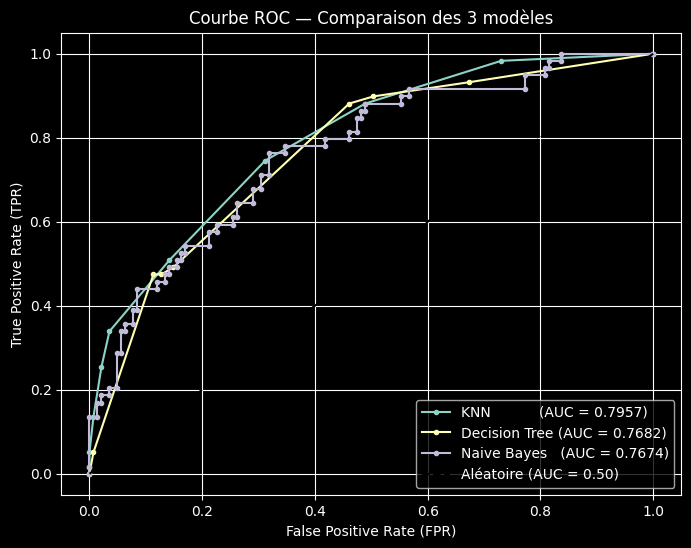


AUC - KNN          : 0.7957
AUC - Decision Tree: 0.7682
AUC - Naive Bayes  : 0.7674


In [14]:
from sklearn.metrics import roc_curve

# Probabilités pour la courbe ROC
y_test_bin = (y_test == 2).astype(int)

y_prob_knn  = best_knn.predict_proba(X_test_scaled)[:, 1]
y_prob_tree = best_tree.predict_proba(X_test)[:, 1]
y_prob_nb   = best_nb.predict_proba(X_test)[:, 1]

# ==================================================
# Courbe ROC
# =================================================
fpr_knn,  tpr_knn,  _ = roc_curve(y_test_bin, y_prob_knn)
fpr_tree, tpr_tree, _ = roc_curve(y_test_bin, y_prob_tree)
fpr_nb,   tpr_nb,   _ = roc_curve(y_test_bin, y_prob_nb)

auc_knn  = auc(fpr_knn,  tpr_knn)
auc_tree = auc(fpr_tree, tpr_tree)
auc_nb   = auc(fpr_nb,   tpr_nb)

plt.figure(figsize=(8, 6))

plt.plot(fpr_knn,  tpr_knn,  marker='.', label=f'KNN           (AUC = {auc_knn:.4f})')
plt.plot(fpr_tree, tpr_tree, marker='.', label=f'Decision Tree (AUC = {auc_tree:.4f})')
plt.plot(fpr_nb,   tpr_nb,   marker='.', label=f'Naive Bayes   (AUC = {auc_nb:.4f})')

# Ligne de référence (modèle aléatoire)
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.50)')

plt.title("Courbe ROC — Comparaison des 3 modèles")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"\nAUC - KNN          : {auc_knn:.4f}")
print(f"AUC - Decision Tree: {auc_tree:.4f}")
print(f"AUC - Naive Bayes  : {auc_nb:.4f}")

## Choix du modèle pour la mise en production | German Credit Risk

